In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('Islamadad_properties_cleaned_v2.csv').drop_duplicates()

In [4]:
df.head()

,property_type,society,location,areaWithType,area,bedRoom,bathroom,balcony,floorNum,facing,agePossession,price_per_sqft,price_in_crore,built_up_area,carpet_area,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room,furnishing_type,luxury_score
0,flat,DHA Phase 1 Apartments,DHA Phase 1,Carpet area: 791 (73.49 sq.m.),793.0,2,2,1,3,North-East,Moderately Old,23596.0,1.87,NaN,791.0,0,0,0,1,0,1,17
1,flat,G-15 Residency,G-15,Carpet area: 870 (80.83 sq.m.),870.0,2,2,3,3,East,New Property,21505.0,1.87,NaN,870.0,1,0,0,0,0,1,39
2,flat,Bahria Town Heights,Bahria Town,Carpet area: 946 (87.89 sq.m.),947.0,3,3,2,6,South,Under Construction,19433.0,1.84,NaN,946.0,0,1,0,0,0,2,8
3,flat,G-12 Homes,G-12,Carpet area: 1321 (122.72 sq.m.),1322.0,3,4,3,9,North,Old Property,14069.0,1.86,NaN,1321.0,0,0,0,1,0,0,17
4,flat,G-12 Plaza,G-12,Carpet area: 354 (32.89 sq.m.),356.0,1,1,1,1,West,Moderately Old,14319.0,0.51,NaN,354.0,1,0,0,0,0,0,27


In [5]:
df.duplicated().sum()

0

<Axes: xlabel='property_type'>

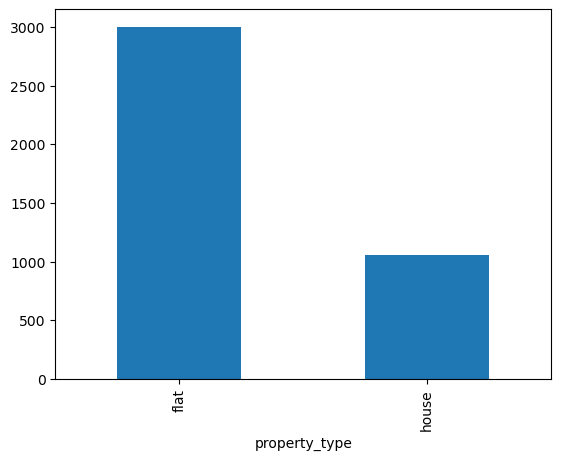

In [6]:
df['property_type'].value_counts().plot(kind='bar')

In [7]:
df['society'].value_counts().shape

(240,)

In [8]:
df['society'].value_counts()

society
Bahria Town Homes       43
I-8 Heights             42
Margalla Hills Homes    40
G-14 Plaza              39
F-11 Plaza              37
                        ..
e-7 residency            4
f-10 villas              3
f-6 heights              3
g-13 enclave             2
e-7 gardens              1
Name: count, Length: 240, dtype: int64

In [9]:
'''society_counts = df['society'].value_counts()

frequency_bins={
    "very_high (<100)":(society_counts>100).sum(),
    "high (50-100)":((society_counts>=50)&(society_counts<=100).sum()),
    "high (10-49)":((society_counts>=10)&(society_counts<=49).sum()),
    "high (2-9)":((society_counts>=2)&(society_counts<=9).sum()),
    "very_low (1)":(society_counts==1).sum()
}'''

'society_counts = df[\'society\'].value_counts()\n\nfrequency_bins={\n    "very_high (<100)":(society_counts>100).sum(),\n    "high (50-100)":((society_counts>=50)&(society_counts<=100).sum()),\n    "high (10-49)":((society_counts>=10)&(society_counts<=49).sum()),\n    "high (2-9)":((society_counts>=2)&(society_counts<=9).sum()),\n    "very_low (1)":(society_counts==1).sum()\n}'

In [10]:
#frequency_bins

In [11]:
df['location'].value_counts().shape

(26,)

<Axes: xlabel='location'>

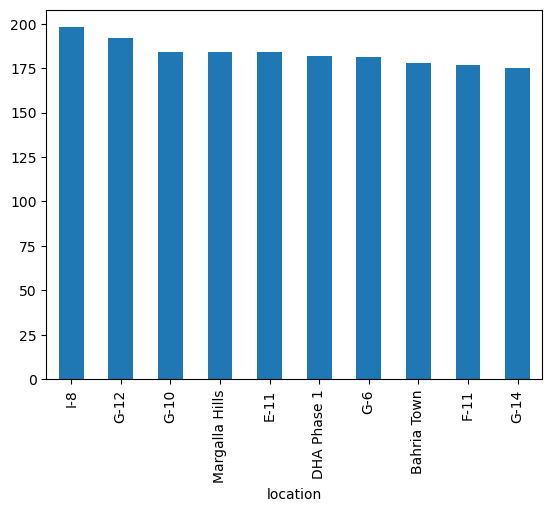

In [12]:
df['location'].value_counts().head(10).plot(kind = 'bar')

In [13]:
df['price_in_crore'].describe()

count    4054.000000
mean        2.139502
std         1.711671
min         0.280000
25%         1.070000
50%         1.680000
75%         2.640000
max        18.210000
Name: price_in_crore, dtype: float64

<Axes: xlabel='price_in_crore', ylabel='Count'>

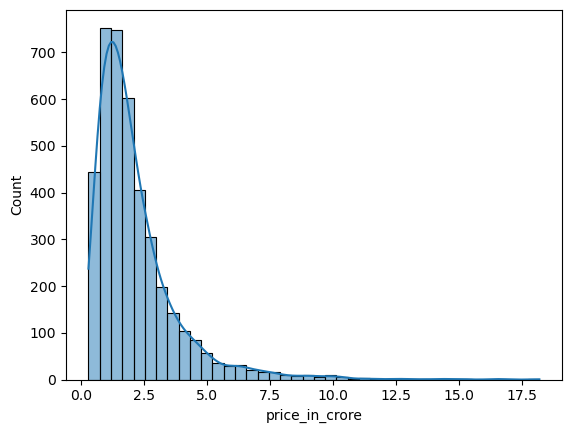

In [14]:
sns.histplot(df['price_in_crore'],kde=True,bins=40)

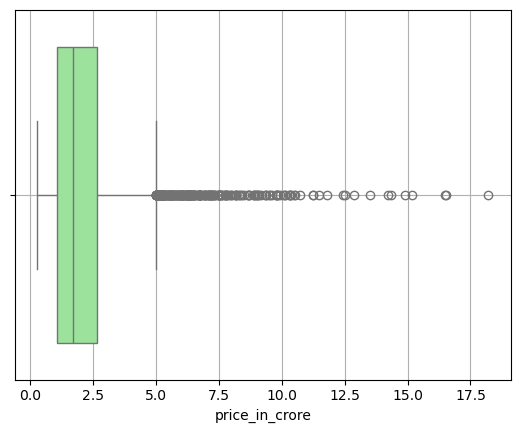

In [15]:
sns.boxplot(x= df['price_in_crore'],color = 'lightgreen')
plt.grid()

In [16]:
kurtosis = df['price_in_crore'].kurt()
#tells how much outliers are in our data.....above 3 is considerable 

In [17]:
print(kurtosis)

12.22059932360892


In [18]:
quantiles = df['price_in_crore'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles


0.01    0.3700
0.05    0.5400
0.95    5.2535
0.99    9.0094
Name: price_in_crore, dtype: float64

In [19]:
Q1 =df['price_in_crore'].describe()['25%']
Q3 = df['price_in_crore'].describe()['75%']
IQR = Q3 - Q1

IQR
#values that are exist in the range of 50%

1.57

In [20]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.285 4.995


In [21]:
outliers = df[(df['price_in_crore'] < lower_bound) | (df['price_in_crore'] > upper_bound)]
outliers.shape

(241, 22)

In [22]:
outliers['price_in_crore'].describe()

count    241.000000
mean       7.202905
std        2.297291
min        5.000000
25%        5.580000
50%        6.470000
75%        7.970000
max       18.210000
Name: price_in_crore, dtype: float64

<Axes: xlabel='price_in_crore'>

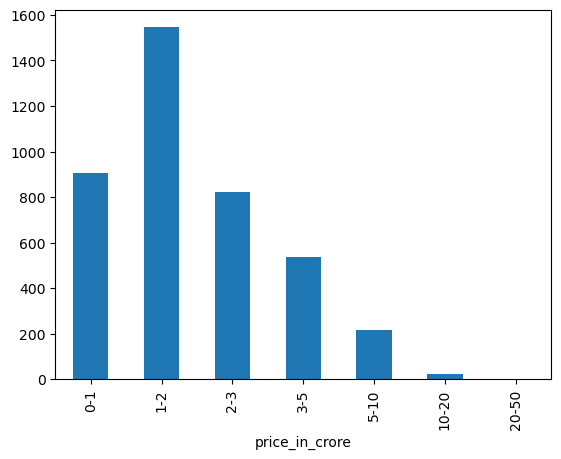

In [23]:
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price_in_crore'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

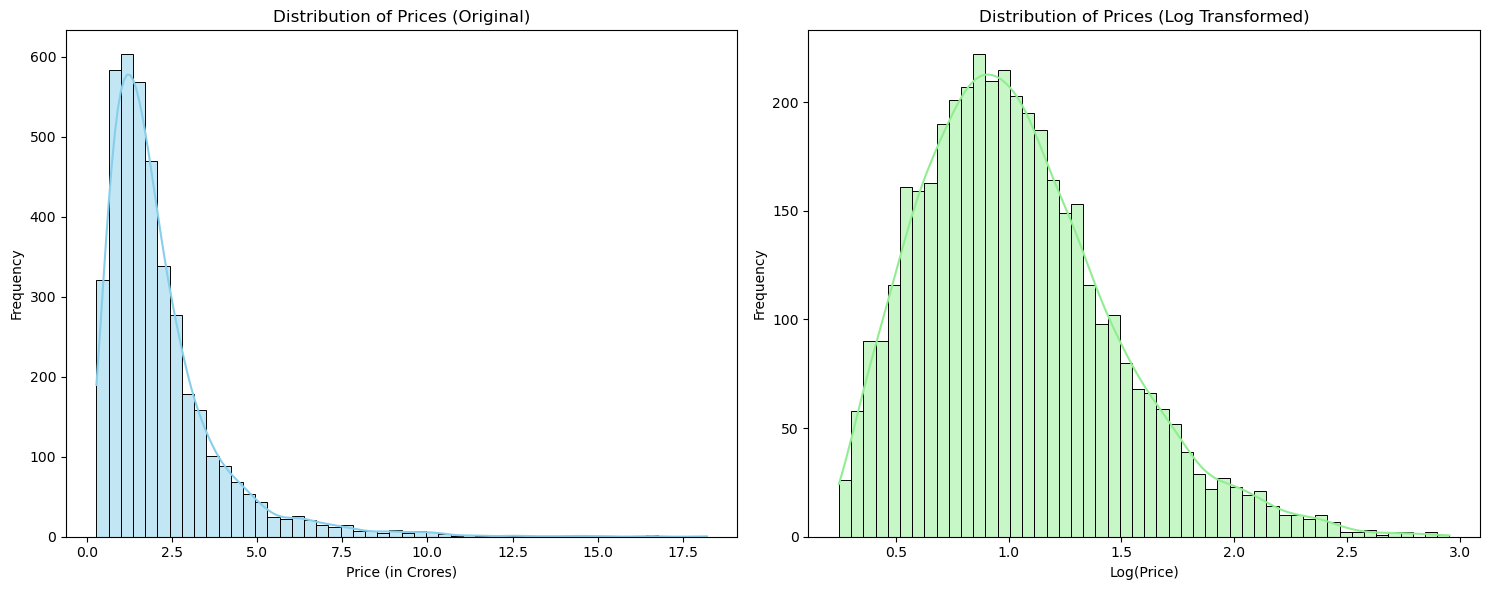

In [24]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price_in_crore'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price_in_crore']),kde = True , bins = 50 , color = 'lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

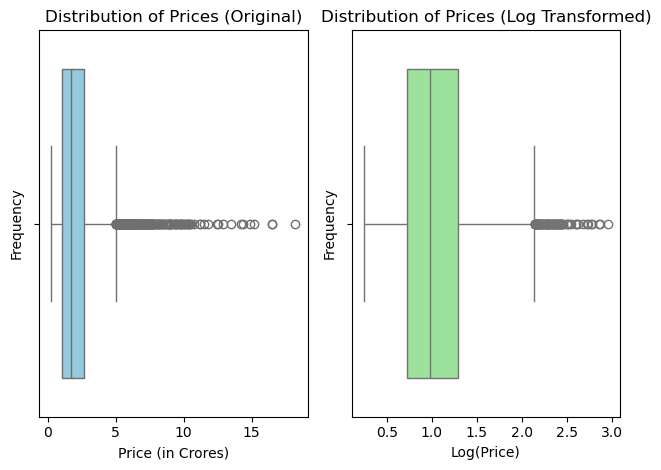

In [25]:
plt.subplot(1, 2, 1)
sns.boxplot(x =df['price_in_crore'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(x =np.log1p(df['price_in_crore']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [26]:

df['price_per_sqft'].describe()

count     4054.000000
mean     19448.927232
std       9292.790332
min       5026.000000
25%      12680.750000
50%      17090.000000
75%      23538.000000
max      59693.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

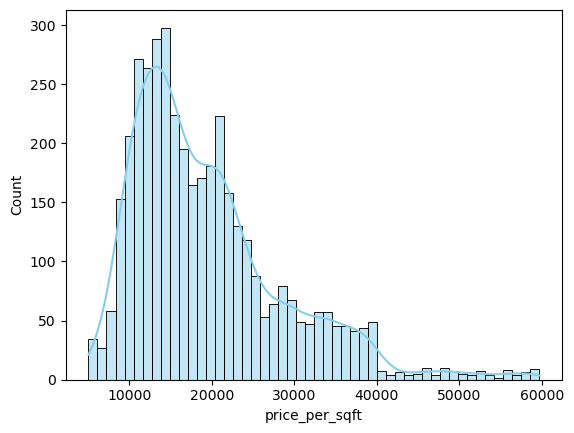

In [27]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

<Axes: xlabel='price_per_sqft'>

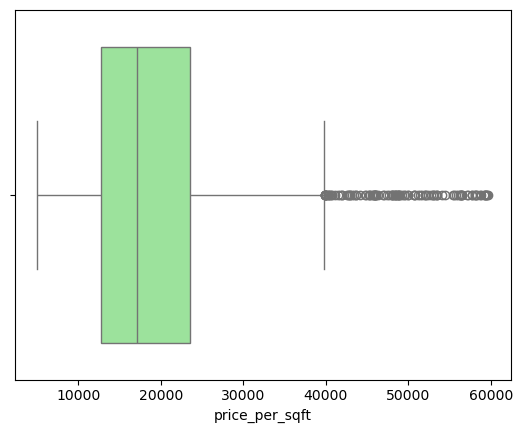

In [28]:

sns.boxplot(x =df['price_per_sqft'], color='lightgreen')

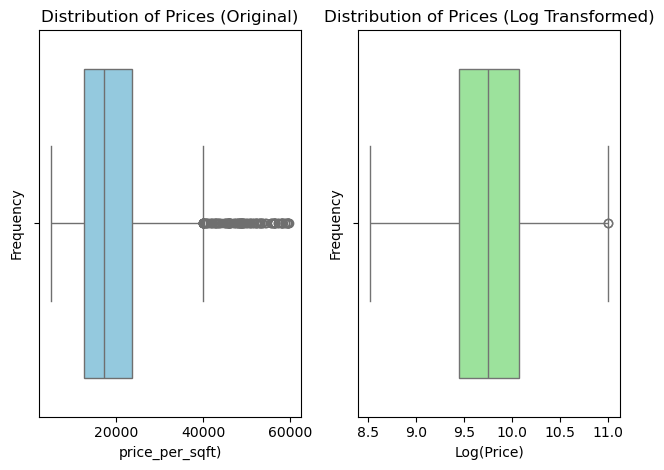

In [29]:
plt.subplot(1, 2, 1)
sns.boxplot(x =df['price_per_sqft'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('price_per_sqft)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(x =np.log1p(df['price_per_sqft']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

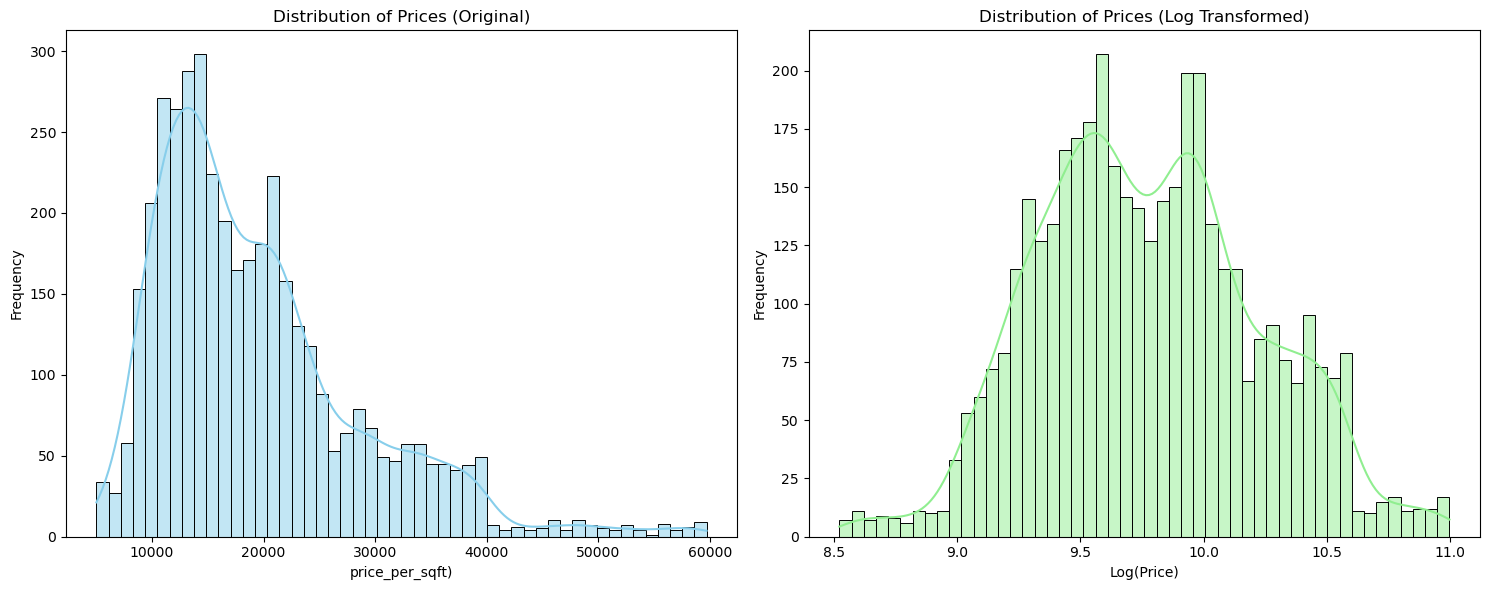

In [30]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price_per_sqft'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('price_per_sqft)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price_per_sqft']),kde = True , bins = 50 , color = 'lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [31]:
df['bedRoom'].isnull().sum()

0

<Axes: xlabel='bedRoom'>

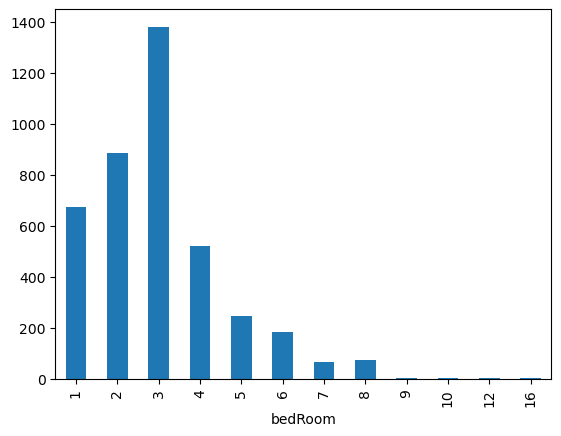

In [32]:

df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

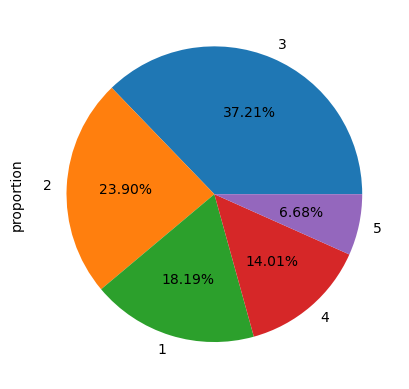

In [33]:
df['bedRoom'].value_counts(normalize = True).head().plot(kind='pie',autopct='%0.2f%%')

<Axes: xlabel='bathroom'>

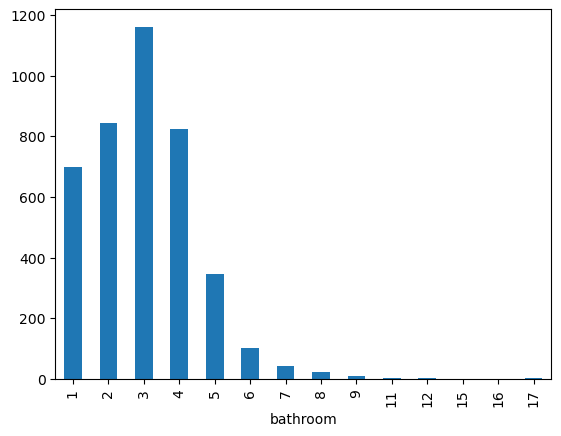

In [34]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

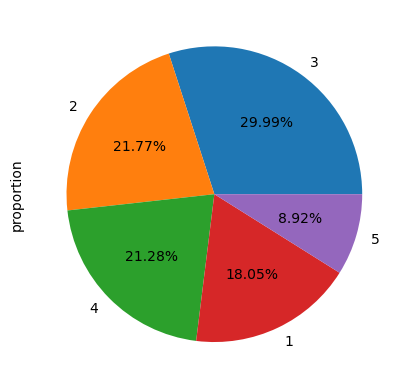

In [35]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [36]:

df.head()

,property_type,society,location,areaWithType,area,bedRoom,bathroom,balcony,floorNum,facing,agePossession,price_per_sqft,price_in_crore,built_up_area,carpet_area,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room,furnishing_type,luxury_score
0,flat,DHA Phase 1 Apartments,DHA Phase 1,Carpet area: 791 (73.49 sq.m.),793.0,2,2,1,3,North-East,Moderately Old,23596.0,1.87,NaN,791.0,0,0,0,1,0,1,17
1,flat,G-15 Residency,G-15,Carpet area: 870 (80.83 sq.m.),870.0,2,2,3,3,East,New Property,21505.0,1.87,NaN,870.0,1,0,0,0,0,1,39
2,flat,Bahria Town Heights,Bahria Town,Carpet area: 946 (87.89 sq.m.),947.0,3,3,2,6,South,Under Construction,19433.0,1.84,NaN,946.0,0,1,0,0,0,2,8
3,flat,G-12 Homes,G-12,Carpet area: 1321 (122.72 sq.m.),1322.0,3,4,3,9,North,Old Property,14069.0,1.86,NaN,1321.0,0,0,0,1,0,0,17
4,flat,G-12 Plaza,G-12,Carpet area: 354 (32.89 sq.m.),356.0,1,1,1,1,West,Moderately Old,14319.0,0.51,NaN,354.0,1,0,0,0,0,0,27


<Axes: xlabel='balcony'>

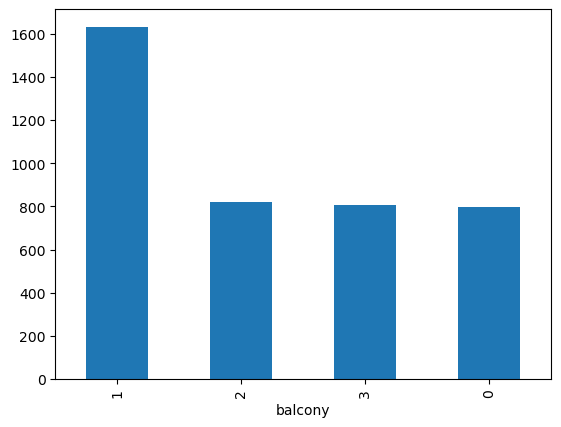

In [37]:

df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

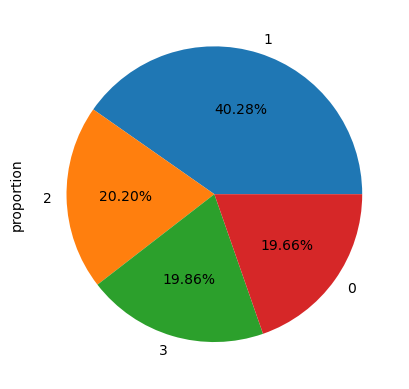

In [38]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [39]:
df['floorNum'].describe()

count    4054.000000
mean        4.002713
std         3.834182
min         0.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        20.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

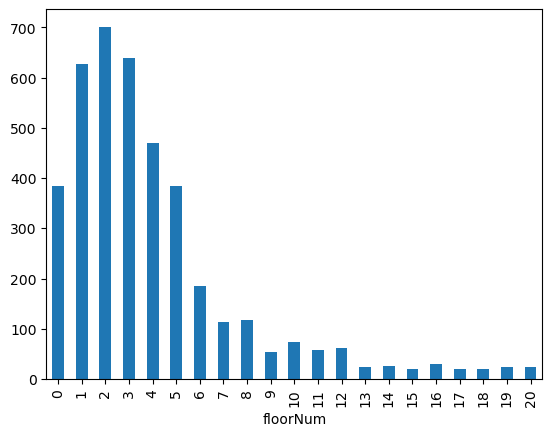

In [40]:

df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='floorNum'>

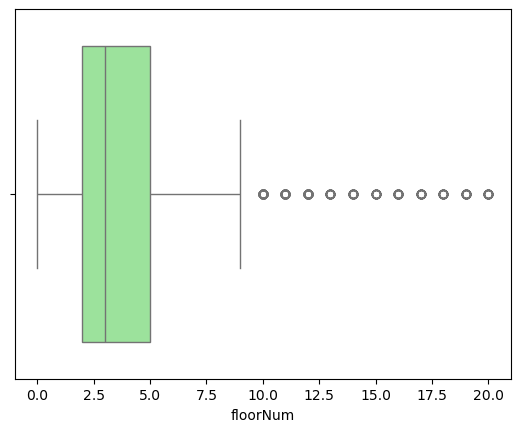

In [41]:
sns.boxplot(x =df['floorNum'], color='lightgreen')

In [42]:
df['facing'].value_counts()

facing
North         552
South-West    535
South         534
West          498
North-East    491
East          488
South-East    481
North-West    475
Name: count, dtype: int64

In [43]:
df['agePossession'].value_counts()

agePossession
Just Completed        712
Old Property          698
Relatively New        687
Under Construction    657
Moderately Old        656
New Property          644
Name: count, dtype: int64

In [44]:
# super built up area
df['built_up_area'].isnull().sum()

3000

In [45]:

df['built_up_area'].describe()

count    1054.000000
mean     1594.969639
std       829.740147
min       600.000000
25%       806.500000
50%      1474.500000
75%      2058.750000
max      6423.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

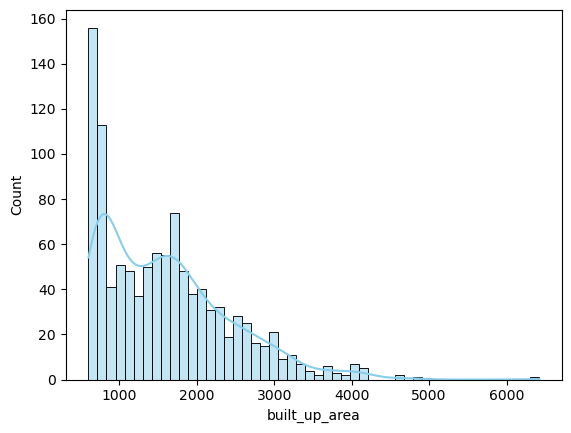

In [46]:
sns.histplot(df['built_up_area'].dropna(), kde = True ,bins=50, color='skyblue')

<Axes: xlabel='built_up_area'>

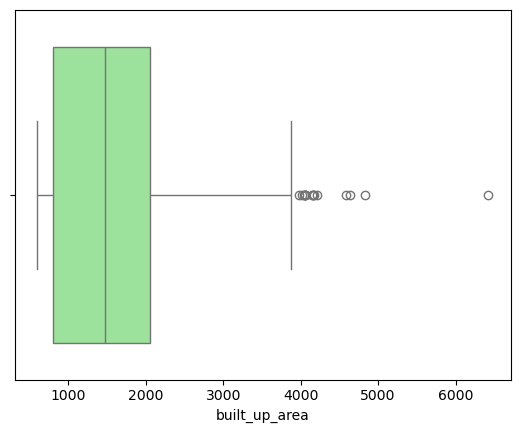

In [47]:
sns.boxplot(x = df['built_up_area'].dropna(), color='lightgreen')

In [48]:
df['carpet_area'].isnull().sum()

1054

In [49]:
df['carpet_area'].describe()

count    3000.000000
mean      919.827667
std       373.991220
min       350.000000
25%       637.000000
50%       905.000000
75%      1169.000000
max      2441.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

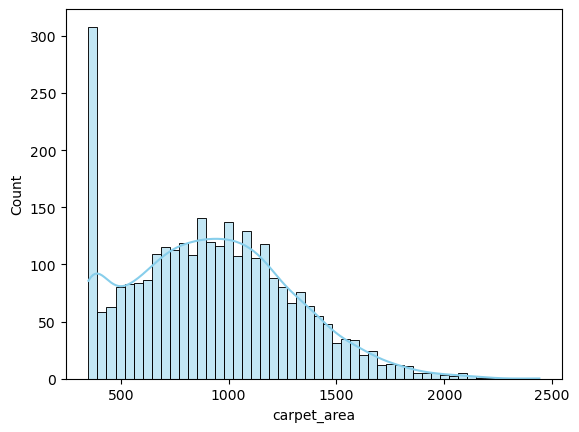

In [50]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: xlabel='carpet_area'>

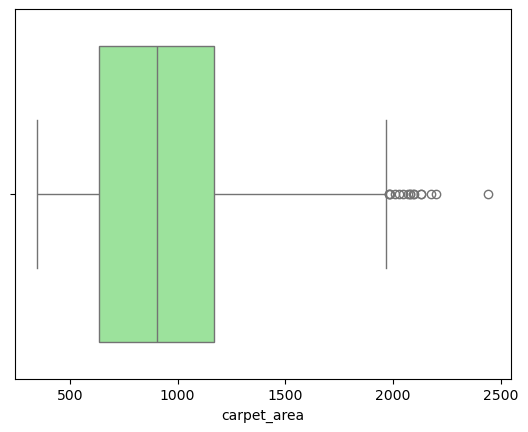

In [51]:

sns.boxplot(x =df['carpet_area'].dropna(), color='lightgreen')

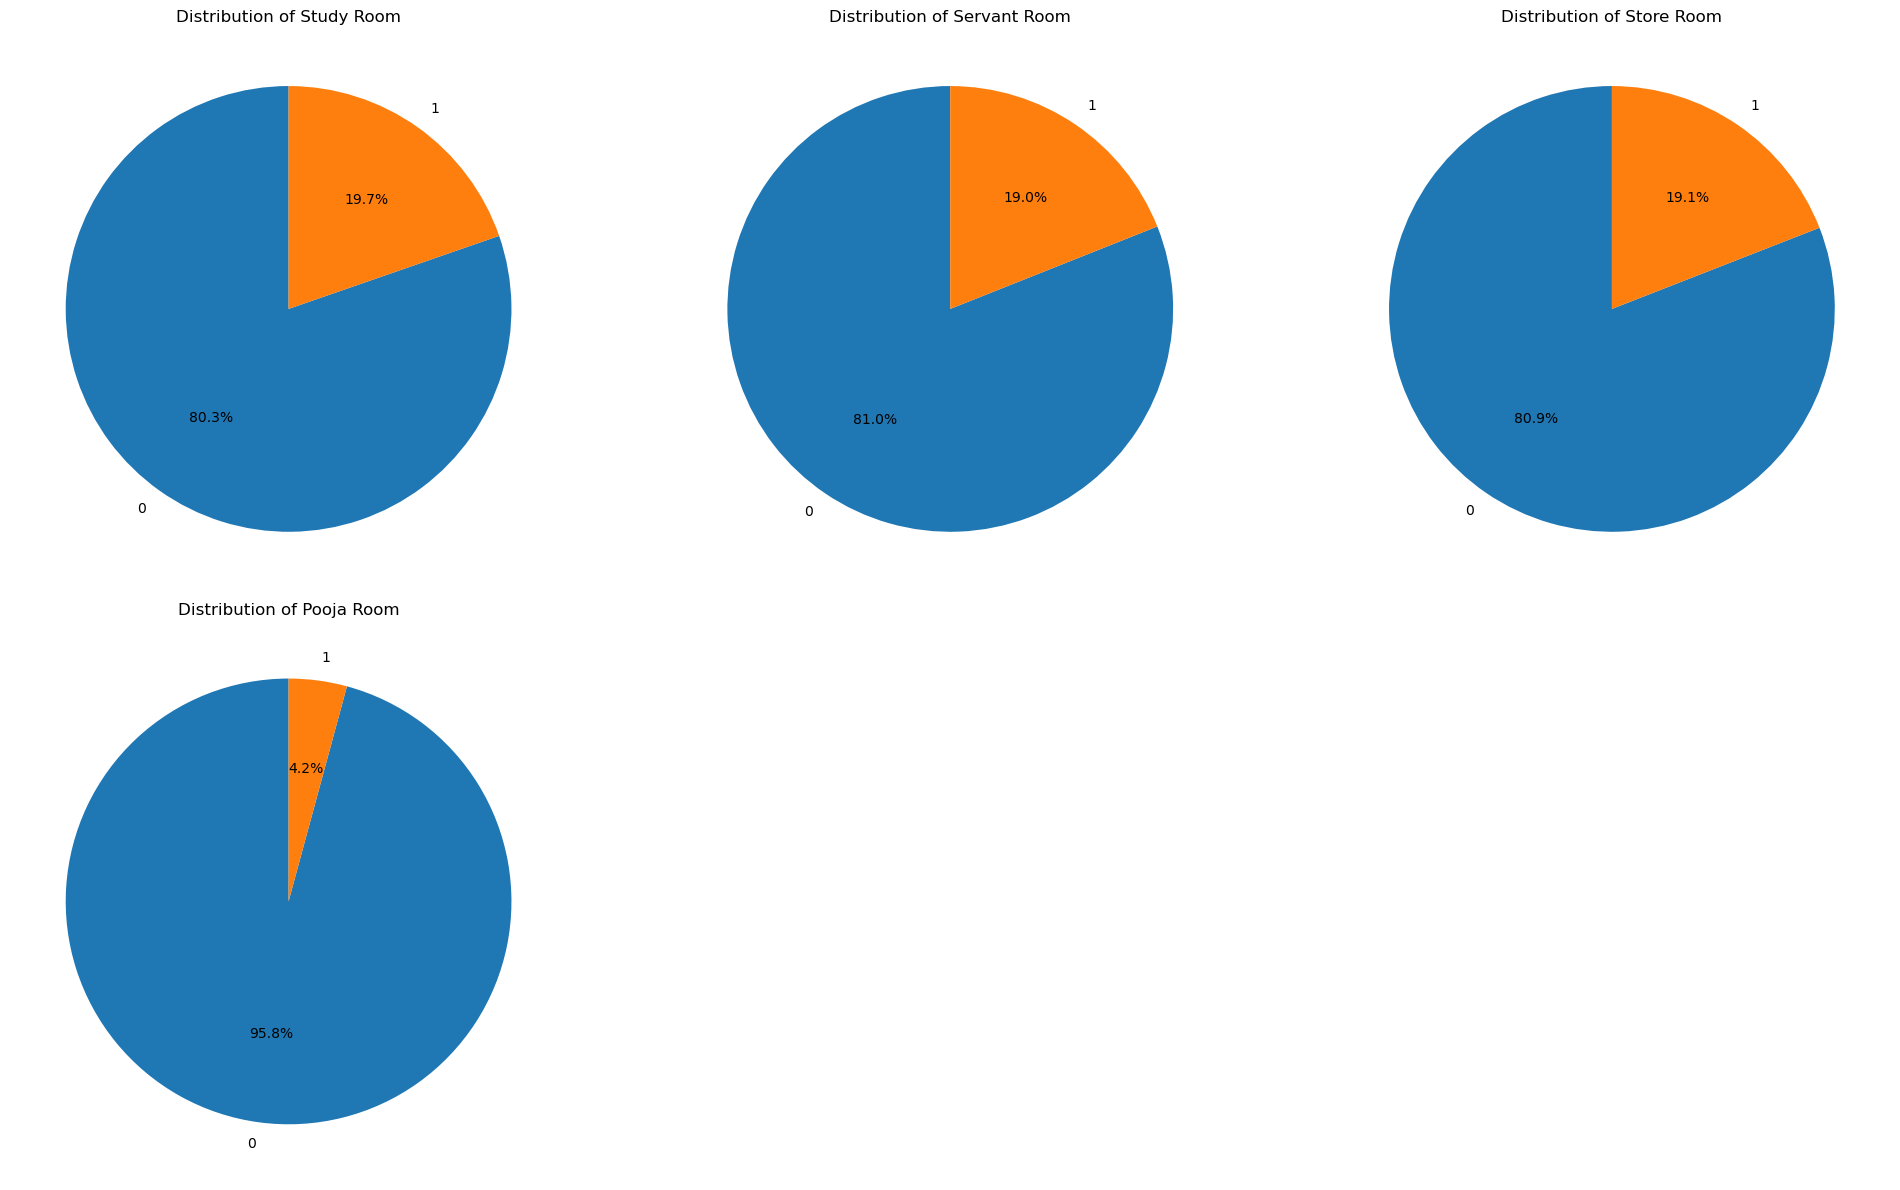

In [52]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['Study Room','Servant Room','Store Room','Pooja Room'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [53]:
df.head()

,property_type,society,location,areaWithType,area,bedRoom,bathroom,balcony,floorNum,facing,agePossession,price_per_sqft,price_in_crore,built_up_area,carpet_area,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room,furnishing_type,luxury_score
0,flat,DHA Phase 1 Apartments,DHA Phase 1,Carpet area: 791 (73.49 sq.m.),793.0,2,2,1,3,North-East,Moderately Old,23596.0,1.87,NaN,791.0,0,0,0,1,0,1,17
1,flat,G-15 Residency,G-15,Carpet area: 870 (80.83 sq.m.),870.0,2,2,3,3,East,New Property,21505.0,1.87,NaN,870.0,1,0,0,0,0,1,39
2,flat,Bahria Town Heights,Bahria Town,Carpet area: 946 (87.89 sq.m.),947.0,3,3,2,6,South,Under Construction,19433.0,1.84,NaN,946.0,0,1,0,0,0,2,8
3,flat,G-12 Homes,G-12,Carpet area: 1321 (122.72 sq.m.),1322.0,3,4,3,9,North,Old Property,14069.0,1.86,NaN,1321.0,0,0,0,1,0,0,17
4,flat,G-12 Plaza,G-12,Carpet area: 354 (32.89 sq.m.),356.0,1,1,1,1,West,Moderately Old,14319.0,0.51,NaN,354.0,1,0,0,0,0,0,27


In [54]:
df['furnishing_type'].value_counts()

furnishing_type
0    1805
1    1288
2     961
Name: count, dtype: int64

<Axes: ylabel='count'>

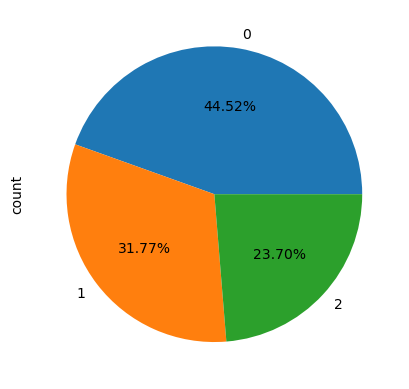

In [83]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [112]:
df['luxury_score'].isnull().sum()

0

In [114]:

df['luxury_score'].describe()

count    4054.000000
mean       32.248150
std        12.207176
min         7.000000
25%        23.000000
50%        33.000000
75%        43.000000
max        57.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

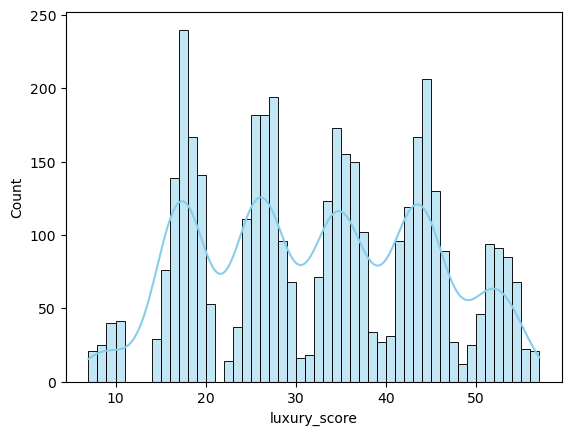

In [116]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: xlabel='luxury_score'>

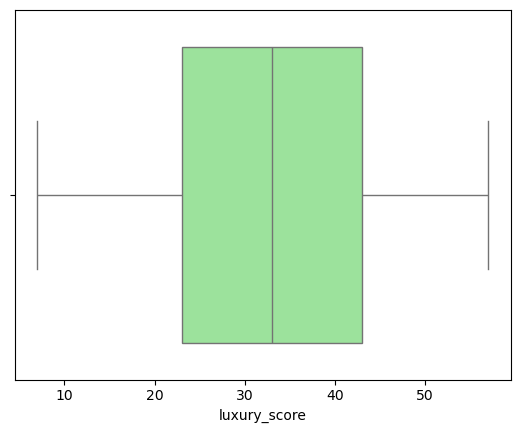

In [122]:
sns.boxplot(x = df['luxury_score'], color='lightgreen')

In [124]:
df.head()

,property_type,society,location,areaWithType,area,bedRoom,bathroom,balcony,floorNum,facing,agePossession,price_per_sqft,price_in_crore,built_up_area,carpet_area,Study Room,Store Room,Servant Room,Prayer Room,Pooja Room,furnishing_type,luxury_score
0,flat,DHA Phase 1 Apartments,DHA Phase 1,Carpet area: 791 (73.49 sq.m.),793.0,2,2,1,3,North-East,Moderately Old,23596.0,1.87,NaN,791.0,0,0,0,1,0,1,17
1,flat,G-15 Residency,G-15,Carpet area: 870 (80.83 sq.m.),870.0,2,2,3,3,East,New Property,21505.0,1.87,NaN,870.0,1,0,0,0,0,1,39
2,flat,Bahria Town Heights,Bahria Town,Carpet area: 946 (87.89 sq.m.),947.0,3,3,2,6,South,Under Construction,19433.0,1.84,NaN,946.0,0,1,0,0,0,2,8
3,flat,G-12 Homes,G-12,Carpet area: 1321 (122.72 sq.m.),1322.0,3,4,3,9,North,Old Property,14069.0,1.86,NaN,1321.0,0,0,0,1,0,0,17
4,flat,G-12 Plaza,G-12,Carpet area: 354 (32.89 sq.m.),356.0,1,1,1,1,West,Moderately Old,14319.0,0.51,NaN,354.0,1,0,0,0,0,0,27
